In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# Deepfake detection with a Vision Transformer (ViT) classifier
# Run in Colab / Jupyter. Adjust DATASET_ROOT to your dataset path.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

# ---------- USER-CONFIG ----------
DATASET_ROOT = "/content/drive/MyDrive/archive (3)"   # directory containing subfolders for classes (e.g., 'real','fake')
IMG_SIZE = (128, 128)               # use 224 for speed; change to (380,380) if required by your pretrained backbone
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE
PATCH_SIZE = 16
PROJECTION_DIM = 32
NUM_HEADS = 2
TRANSFORMER_LAYERS = 2
MLP_HEAD_UNITS = [256]        # classifier MLP head (smaller than 2048 for speed)
DROPOUT_RATE = 0.1
EPOCHS = 10                          # start small; callbacks will stop early if no improvement
NUM_CLASSES = 1                     # binary: deepfake (1) vs real (0)
LEARNING_RATE = 1e-4
MODEL_SAVE_PATH = "vit_deepfake_best.h5"
# ----------------------------------

# Optional: enable mixed precision for speed on GPUs
try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled:", mixed_precision.global_policy())
except Exception:
    print("Mixed precision not available or already set.")

# ---------- data pipeline ----------
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

class_names = train_ds.class_names
print("Detected classes:", class_names)

# Fast in-graph augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.06),
    layers.RandomZoom(0.08),
    # Add any other lightweight transforms if needed
])

# Preprocessing: convert to float32 [0..1]
def preprocess(x, y):
    x = tf.image.convert_image_dtype(x, tf.float32)
    return x, y

train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE)

# Apply augmentation only on training, then cache and prefetch
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

# ---------- ViT model implementation ----------
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1,1,1,1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patchs):
        x = self.projection(patchs)
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        pos_embed = self.position_embedding(positions)
        return x + pos_embed

class TransformerBlock(layers.Layer):
    def __init__(self, projection_dim, num_heads, mlp_dim, dropout=DROPOUT_RATE):
        super().__init__()
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim)
        self.dropout1 = layers.Dropout(dropout)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = keras.Sequential([
            layers.Dense(mlp_dim, activation=tf.nn.gelu),
            layers.Dropout(dropout),
            layers.Dense(projection_dim),
            layers.Dropout(dropout),
        ])

    def call(self, inputs, training=False):
        x_norm = self.norm1(inputs)
        attn_out = self.att(x_norm, x_norm)
        attn_out = self.dropout1(attn_out, training=training)
        x1 = attn_out + inputs
        x_norm2 = self.norm2(x1)
        mlp_out = self.mlp(x_norm2, training=training)
        return mlp_out + x1

def build_vit_classifier(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    projection_dim=PROJECTION_DIM,
    num_heads=NUM_HEADS,
    transformer_layers=TRANSFORMER_LAYERS,
    mlp_head_units=MLP_HEAD_UNITS,
    num_classes=NUM_CLASSES,
):
    inputs = layers.Input(shape=img_size + (3,))
    # Create patches
    patches = Patches(patch_size)(inputs)
    fixed_num_patches = (img_size[0] // patch_size) * (img_size[1] // patch_size)
    x = PatchEncoder(fixed_num_patches, projection_dim)(patches)

    # Transformer stack
    for _ in range(transformer_layers):
        x = TransformerBlock(projection_dim, num_heads, projection_dim * 4)(x)

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)

    # MLP head
    for units in mlp_head_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(DROPOUT_RATE)(x)

    # final output (binary)
    # ensure output dtype float32 for stability with mixed precision
    outputs = layers.Dense(num_classes, activation="sigmoid", dtype="float32")(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="vit_deepfake")
    return model

# Build and compile
vit_model = build_vit_classifier()
opt = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
vit_model.compile(
    optimizer=opt,
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy"),
             tf.keras.metrics.AUC(name="auc"),
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)

vit_model.summary()

# ---------- Callbacks ----------
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, monitor="val_loss", save_best_only=True, verbose=1)
]

# ---------- Training ----------
history = vit_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

# ---------- Evaluation ----------
print("Evaluating on validation set...")
val_metrics = vit_model.evaluate(val_ds)
print("Validation metrics (loss, accuracy, auc, precision, recall):", val_metrics)

# Save final model (already saved best model via ModelCheckpoint)
vit_model.save("vit_deepfake_final.h5")
print("Model saved.")

# ---------- Quick inference example (optional) ----------
# import numpy as np
# batch_x, batch_y = next(iter(val_ds.take(1)))
# preds = vit_model.predict(batch_x)
# print("Sample predictions:", preds[:8].squeeze())


Mixed precision enabled: <DTypePolicy "mixed_float16">
Found 4082 files belonging to 2 classes.
Using 3266 files for training.
Found 4082 files belonging to 2 classes.
Using 816 files for validation.
Detected classes: ['real_and_fake_face', 'real_and_fake_face_detection']


Model: "vit_deepfake"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patches (Patches)               │ (None, None, 768)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_encoder (PatchEncoder)    │ (None, 64, 32)         │        26,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 64, 32)         │        16,896 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 64, 32)         │        16,896 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ (None, 64, 32)         │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,217 (270.38 KB)

 Trainable params: 69,217 (270.38 KB)

...

409/409 ━━━━━━━━━━━━━━━━━━━━ 249s 423ms/step - accuracy: 0.5055 - auc: 0.4990 - loss: 0.7021 - precision: 0.4934 - recall: 0.4480 - val_accuracy: 0.4767 - val_auc: 0.5086 - val_loss: 0.6960 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.5082 - auc: 0.4998 - loss: 0.6963 - precision: 0.4935 - recall: 0.3543
Epoch 2: val_loss improved from 0.69597 to 0.69378, saving model to vit_deepfake_best.h5


409/409 ━━━━━━━━━━━━━━━━━━━━ 100s 245ms/step - accuracy: 0.5082 - auc: 0.4998 - loss: 0.6963 - precision: 0.4935 - recall: 0.3545 - val_accuracy: 0.4718 - val_auc: 0.4847 - val_loss: 0.6938 - val_precision: 0.3571 - val_recall: 0.0117 - learning_rate: 1.0000e-04
Epoch 3/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.4825 - auc: 0.4710 - loss: 0.6997 - precision: 0.4832 - recall: 0.4632
Epoch 3: val_loss improved from 0.69378 to 0.69333, saving model to vit_deepfake_best.h5


409/409 ━━━━━━━━━━━━━━━━━━━━ 141s 242ms/step - accuracy: 0.4825 - auc: 0.4711 - loss: 0.6997 - precision: 0.4832 - recall: 0.4632 - val_accuracy: 0.5037 - val_auc: 0.4819 - val_loss: 0.6933 - val_precision: 0.5165 - val_recall: 0.8080 - learning_rate: 1.0000e-04
Epoch 4/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.5228 - auc: 0.5091 - loss: 0.6937 - precision: 0.4985 - recall: 0.3508
Epoch 4: val_loss did not improve from 0.69333
409/409 ━━━━━━━━━━━━━━━━━━━━ 98s 240ms/step - accuracy: 0.5227 - auc: 0.5091 - loss: 0.6937 - precision: 0.4985 - recall: 0.3511 - val_accuracy: 0.4767 - val_auc: 0.4732 - val_loss: 0.7040 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 5/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.5012 - auc: 0.4975 - loss: 0.6951 - precision: 0.4813 - recall: 0.2931
Epoch 5: val_loss improved from 0.69333 to 0.69262, saving model to vit_deepfake_best.h5


409/409 ━━━━━━━━━━━━━━━━━━━━ 143s 242ms/step - accuracy: 0.5012 - auc: 0.4975 - loss: 0.6951 - precision: 0.4813 - recall: 0.2934 - val_accuracy: 0.5208 - val_auc: 0.4529 - val_loss: 0.6926 - val_precision: 0.5221 - val_recall: 0.9953 - learning_rate: 1.0000e-04
Epoch 6/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.5064 - auc: 0.5047 - loss: 0.6951 - precision: 0.4857 - recall: 0.4419
Epoch 6: val_loss did not improve from 0.69262
409/409 ━━━━━━━━━━━━━━━━━━━━ 141s 241ms/step - accuracy: 0.5064 - auc: 0.5047 - loss: 0.6951 - precision: 0.4857 - recall: 0.4420 - val_accuracy: 0.4767 - val_auc: 0.4717 - val_loss: 0.6966 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 7/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.4731 - auc: 0.4714 - loss: 0.6981 - precision: 0.4659 - recall: 0.3439
Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 7: val_loss did not improve from 0.69262
409/409 ━━━━━━━━━

Validation metrics (loss, accuracy, auc, precision, recall): [0.6926223039627075, 0.5208333134651184, 0.4528786242008209, 0.522113025188446, 0.9953161478042603]
Model saved.


In [2]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# Ensure true_labels and predictions are available
if 'true_labels' not in locals() or 'predictions' not in locals():
    print("True labels or predictions not found. Generating them now...")
    true_labels = np.concatenate([y for x, y in val_ds], axis=0)
    if true_labels.ndim > 1 and true_labels.shape[1] == 1:
        true_labels = true_labels.flatten()
    predictions = vit_model.predict(val_ds)
    if predictions.ndim > 1 and predictions.shape[1] == 1:
        predictions = predictions.flatten()

# Calculate Mean Absolute Error (MAE)
# MAE is calculated between the true binary labels and the predicted probabilities.
mae = mean_absolute_error(true_labels, predictions)

print(f"Mean Absolute Error (MAE): {mae:.4f}")

True labels or predictions not found. Generating them now...
102/102 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step
Mean Absolute Error (MAE): 0.4995


Extracting features from validation set...
Shape of extracted features: (816, 32)
Shape of covariance matrix: (32, 32)


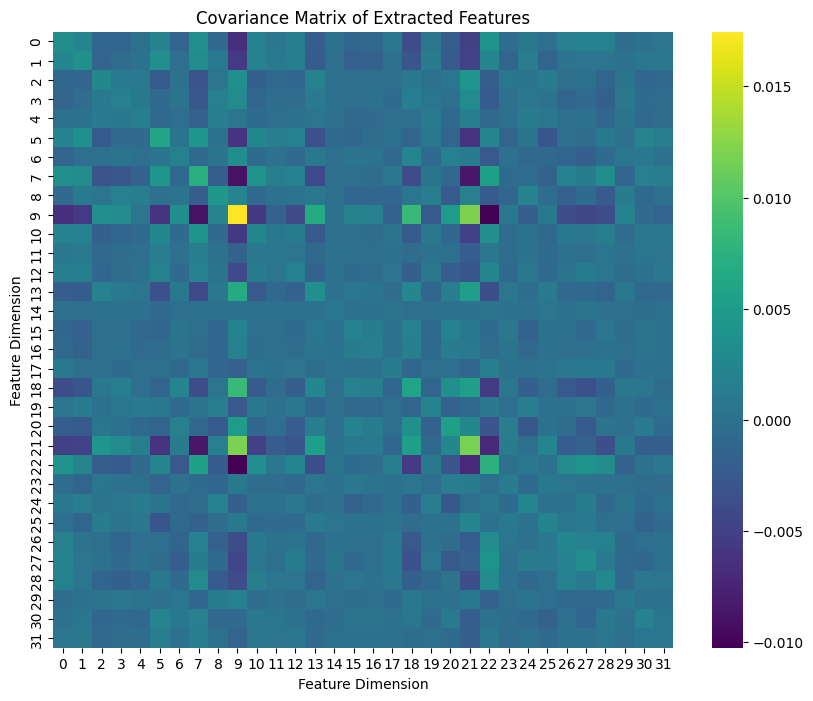

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

# Create a model to extract features from an intermediate layer
# We'll use the output of the GlobalAveragePooling1D layer, right before the MLP head.
feature_extractor = tf.keras.Model(
    inputs=vit_model.inputs,
    outputs=vit_model.get_layer("global_average_pooling1d").output
)

all_features = []

# Iterate through the validation dataset to collect these features
print("Extracting features from validation set...")
for images, _ in val_ds:
    features = feature_extractor.predict(images, verbose=0)
    all_features.append(features)

# Convert the collected features into a NumPy array
all_features = np.concatenate(all_features, axis=0)

print(f"Shape of extracted features: {all_features.shape}")

# Calculate the covariance matrix
covariance_matrix = np.cov(all_features, rowvar=False) # rowvar=False means columns are variables

print(f"Shape of covariance matrix: {covariance_matrix.shape}")

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(covariance_matrix, annot=False, cmap='viridis')
plt.title('Covariance Matrix of Extracted Features')
plt.xlabel('Feature Dimension')
plt.ylabel('Feature Dimension')
plt.show()

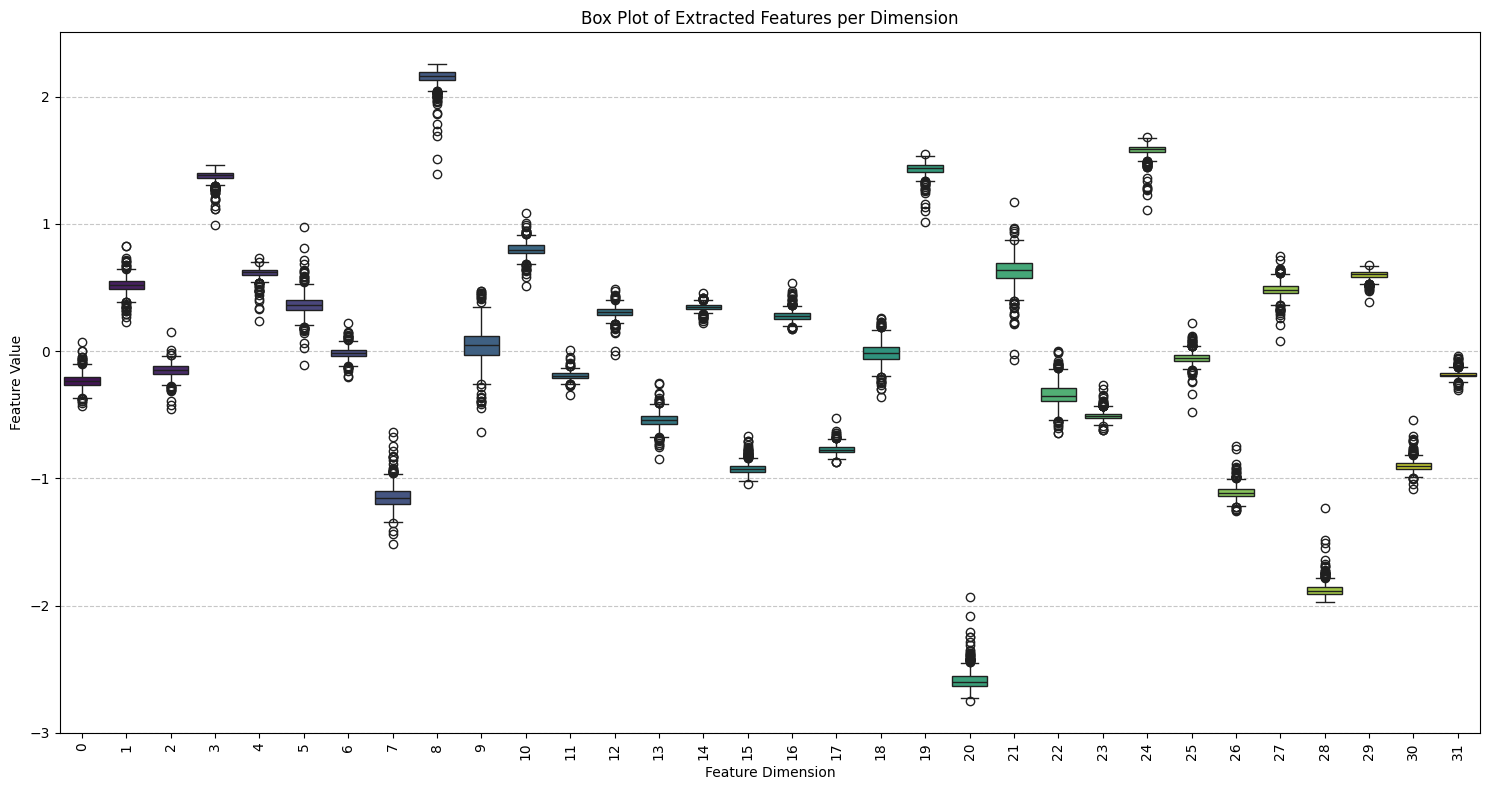

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming 'all_features' is available from previous execution
# (816, 32) in shape

if 'all_features' in locals():
    # Create a DataFrame for easier plotting with seaborn
    df_features = pd.DataFrame(all_features)

    plt.figure(figsize=(15, 8))
    sns.boxplot(data=df_features, palette='viridis')
    plt.title('Box Plot of Extracted Features per Dimension')
    plt.xlabel('Feature Dimension')
    plt.ylabel('Feature Value')
    plt.xticks(rotation=90)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'all_features' not found. Please run the feature extraction cell first.")

Generating predictions for confusion matrix...
102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step


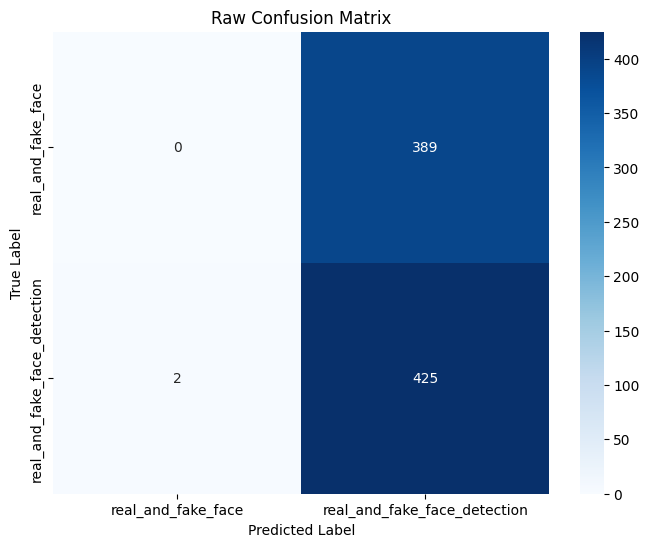

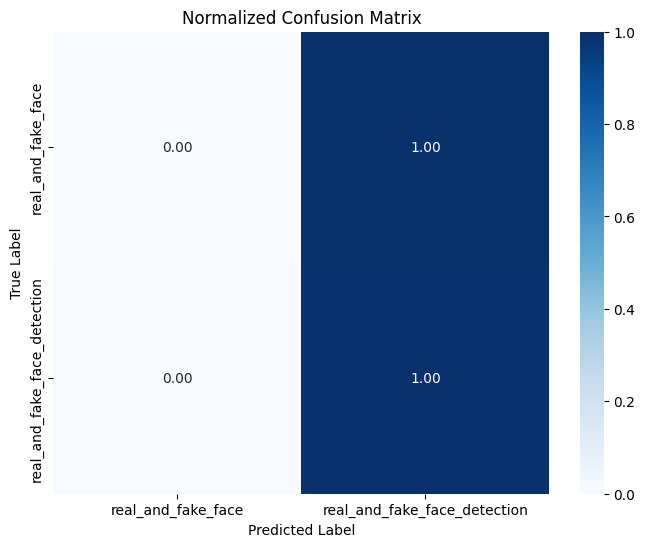


Classification Report:
                              precision    recall  f1-score   support

          real_and_fake_face       0.00      0.00      0.00       389
real_and_fake_face_detection       0.52      1.00      0.68       427

                    accuracy                           0.52       816
                   macro avg       0.26      0.50      0.34       816
                weighted avg       0.27      0.52      0.36       816



In [7]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get true labels from validation dataset
true_labels = np.concatenate([y for x, y in val_ds], axis=0)

# Ensure true_labels are flat if they came as (batch_size, 1)
if true_labels.ndim > 1 and true_labels.shape[1] == 1:
    true_labels = true_labels.flatten()

# 2. Get predicted probabilities for the validation dataset
print("Generating predictions for confusion matrix...")
predictions = vit_model.predict(val_ds)

# 3. Convert probabilities to binary predictions (0 or 1)
predicted_labels = (predictions > 0.5).astype(int)

# Ensure predicted_labels are flat if they came as (batch_size, 1)
if predicted_labels.ndim > 1 and predicted_labels.shape[1] == 1:
    predicted_labels = predicted_labels.flatten()

# 4. Compute the raw confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# 5. Visualize the raw confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Raw Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 6. Compute the normalized confusion matrix
cm_normalized = confusion_matrix(true_labels, predicted_labels, normalize='true')

# 7. Visualize the normalized confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Optionally, print out more detailed metrics
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

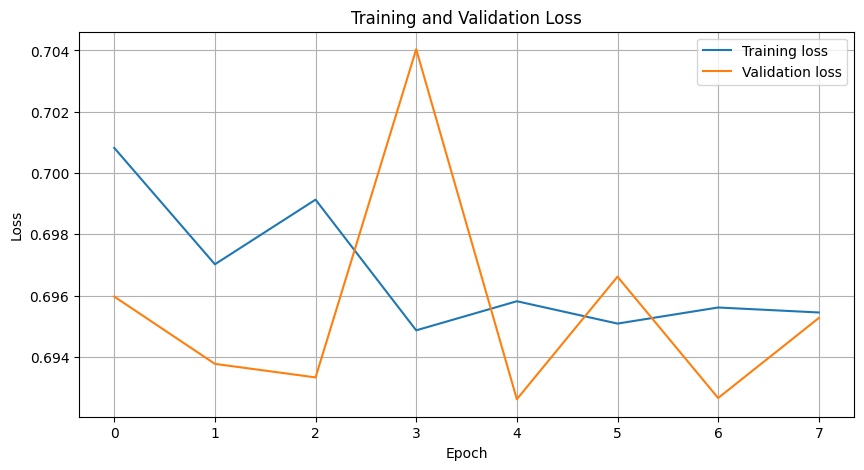

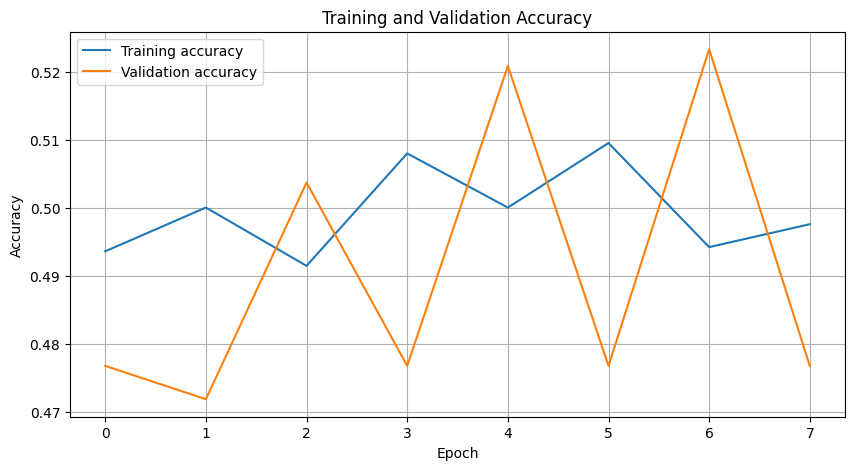

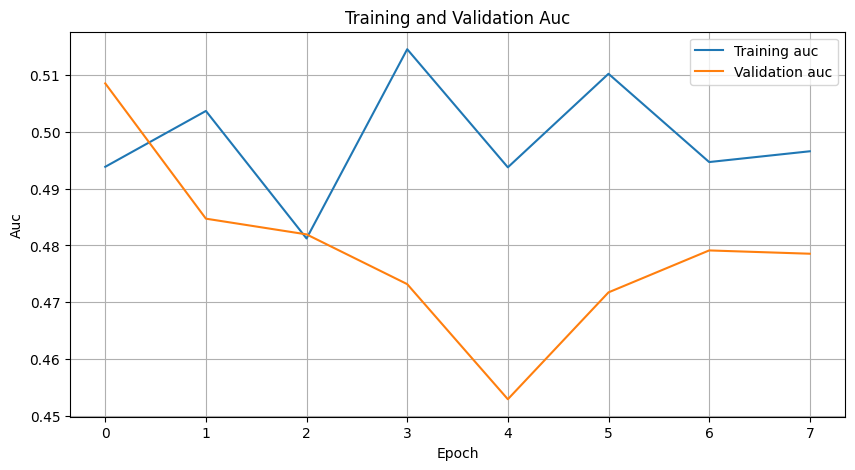

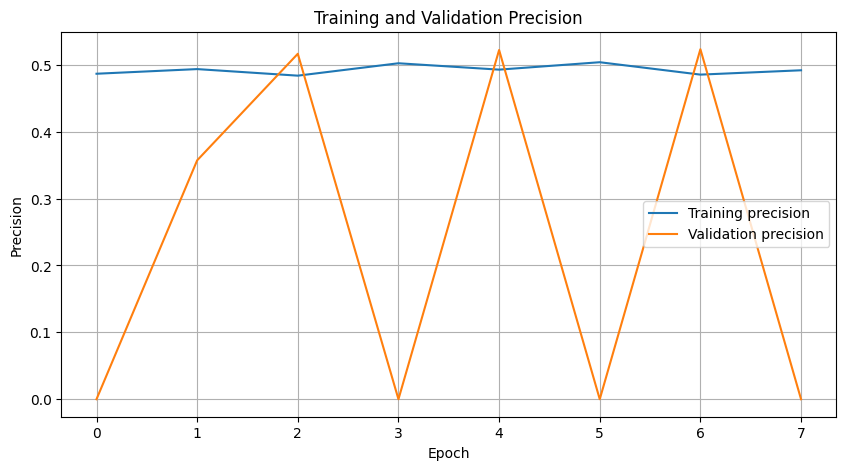

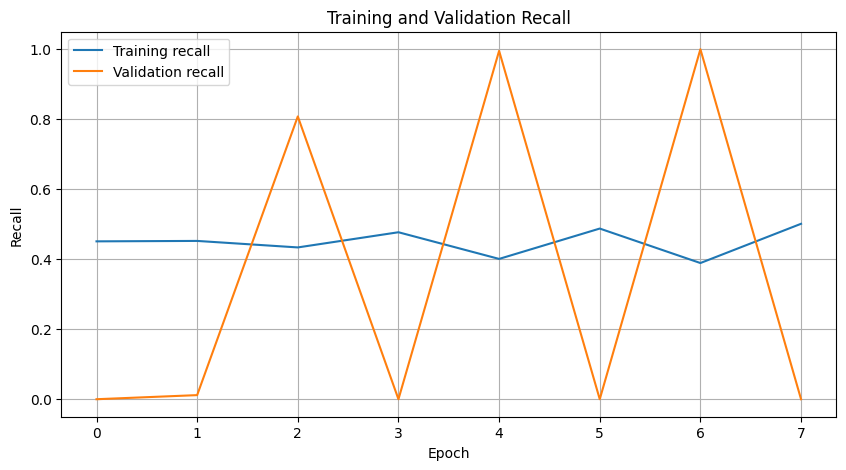

In [8]:
import matplotlib.pyplot as plt

def plot_metrics(history):
    metrics = ['loss', 'accuracy', 'auc', 'precision', 'recall']
    for metric in metrics:
        if metric in history.history and f'val_{metric}' in history.history:
            plt.figure(figsize=(10, 5))
            plt.plot(history.history[metric], label=f'Training {metric}')
            plt.plot(history.history[f'val_{metric}'], label=f'Validation {metric}')
            plt.title(f'Training and Validation {metric.capitalize()}')
            plt.xlabel('Epoch')
            plt.ylabel(metric.capitalize())
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            print(f"Warning: {metric} or val_{metric} not found in history.")

plot_metrics(history)

Generating predictions for ROC curve...
102/102 ━━━━━━━━━━━━━━━━━━━━ 13s 124ms/step


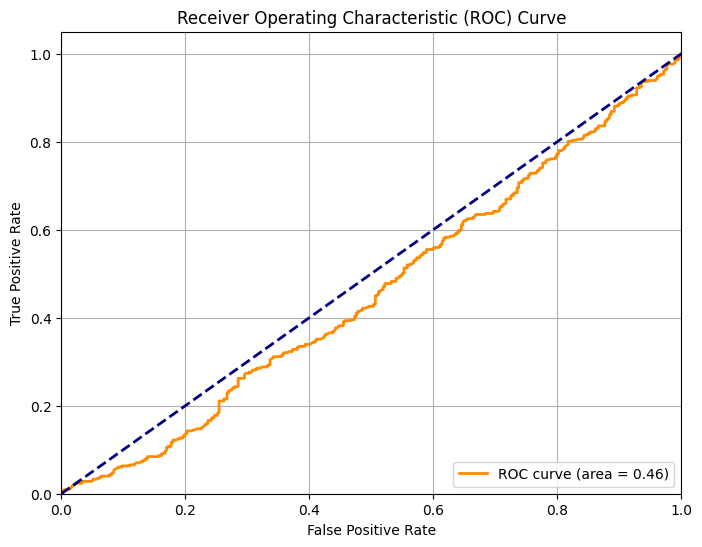

AUC Score: 0.4588


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get true labels from validation dataset (ensure flattened)
true_labels = np.concatenate([y for x, y in val_ds], axis=0)
if true_labels.ndim > 1 and true_labels.shape[1] == 1:
    true_labels = true_labels.flatten()

# Get predicted probabilities for the validation dataset
print("Generating predictions for ROC curve...")
predictions = vit_model.predict(val_ds)

# Ensure predictions are flat if they came as (batch_size, 1)
if predictions.ndim > 1 and predictions.shape[1] == 1:
    predictions = predictions.flatten()

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(true_labels, predictions)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

Generating predictions for Precision-Recall curve...
102/102 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step


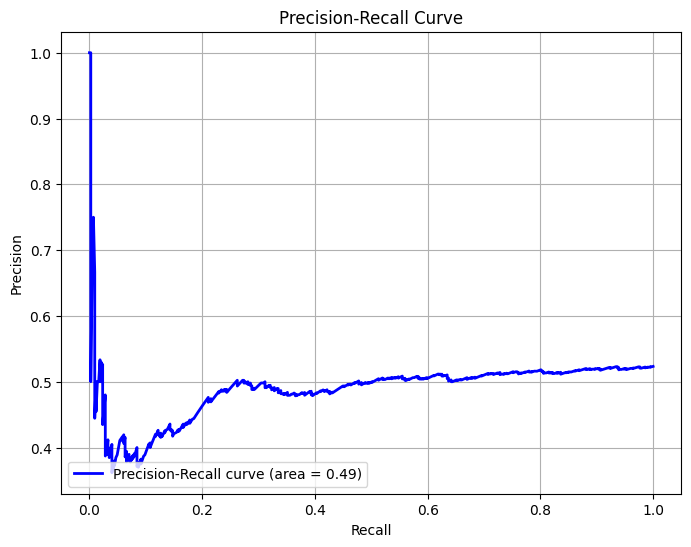

Precision-Recall AUC Score: 0.4896


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Get true labels from validation dataset (ensure flattened)
true_labels = np.concatenate([y for x, y in val_ds], axis=0)
if true_labels.ndim > 1 and true_labels.shape[1] == 1:
    true_labels = true_labels.flatten()

# Get predicted probabilities for the validation dataset
print("Generating predictions for Precision-Recall curve...")
predictions = vit_model.predict(val_ds)

# Ensure predictions are flat if they came as (batch_size, 1)
if predictions.ndim > 1 and predictions.shape[1] == 1:
    predictions = predictions.flatten()

# Calculate Precision-Recall curve and AUC
precision, recall, thresholds = precision_recall_curve(true_labels, predictions)
pr_auc = auc(recall, precision)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label='Precision-Recall curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

print(f"Precision-Recall AUC Score: {pr_auc:.4f}")

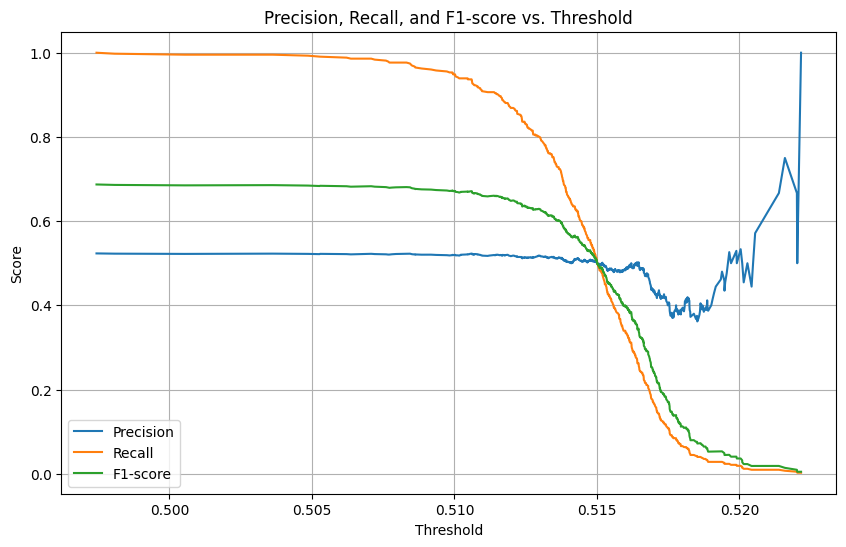

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score

# Ensure true_labels and predictions are available
if 'true_labels' not in locals() or 'predictions' not in locals():
    print("True labels or predictions not found. Generating them now...")
    true_labels = np.concatenate([y for x, y in val_ds], axis=0)
    if true_labels.ndim > 1 and true_labels.shape[1] == 1:
        true_labels = true_labels.flatten()
    predictions = vit_model.predict(val_ds)
    if predictions.ndim > 1 and predictions.shape[1] == 1:
        predictions = predictions.flatten()

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(true_labels, predictions)

# Calculate F1-score for each threshold
f1_scores = []
for t in thresholds:
    binary_predictions = (predictions >= t).astype(int)
    f1_scores.append(f1_score(true_labels, binary_predictions, zero_division=0))

f1_scores = np.array(f1_scores)

# Plot Precision, Recall, and F1-score as a function of threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision') # precision and recall arrays are one element longer than thresholds
plt.plot(thresholds, recall[:-1], label='Recall')
plt.plot(thresholds, f1_scores, label='F1-score')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-score vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()


--- Class Distribution ---
Training Set Class Distribution:
  real_and_fake_face: 1652 samples (50.58%)
  real_and_fake_face_detection: 1614 samples (49.42%)
Total training samples: 3266

Validation Set Class Distribution:
  real_and_fake_face: 389 samples (47.67%)
  real_and_fake_face_detection: 427 samples (52.33%)
Total validation samples: 816

--- Dataset Examples ---


/tmp/ipython-input-952069471.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(labels[i].numpy())])


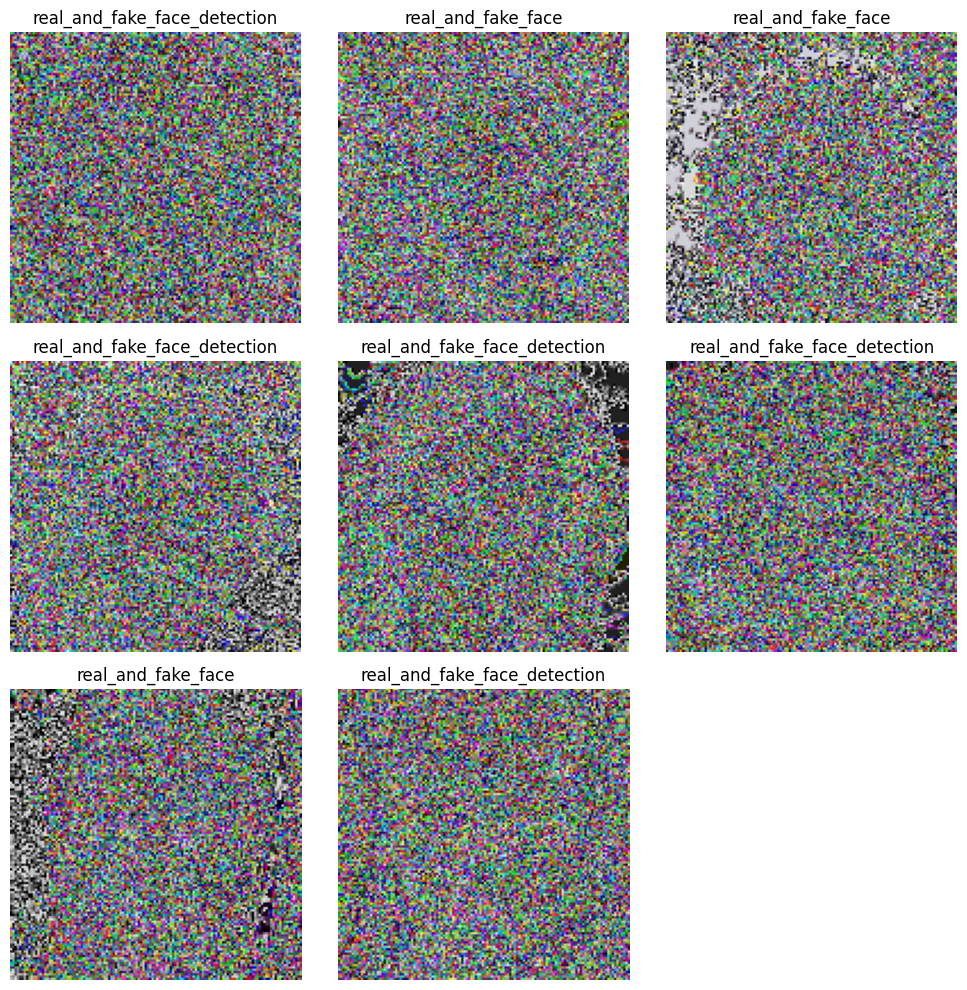

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# --- Class Distribution ---
print("\n--- Class Distribution ---")
def get_class_counts(dataset, class_names):
    counts = {name: 0 for name in class_names}
    total_samples = 0
    for _, labels in dataset:
        unique_labels, counts_per_batch = np.unique(labels.numpy(), return_counts=True)
        for label_idx, count in zip(unique_labels, counts_per_batch):
            # Ensure label_idx is an integer to correctly index class_names
            counts[class_names[int(label_idx)]] += count
        total_samples += len(labels)
    return counts, total_samples


train_counts, total_train = get_class_counts(train_ds, class_names)
val_counts, total_val = get_class_counts(val_ds, class_names)

print("Training Set Class Distribution:")
for cls, count in train_counts.items():
    print(f"  {cls}: {count} samples ({count/total_train:.2%})")
print(f"Total training samples: {total_train}")

print("\nValidation Set Class Distribution:")
for cls, count in val_counts.items():
    print(f"  {cls}: {count} samples ({count/total_val:.2%})")
print(f"Total validation samples: {total_val}")

# --- Dataset Examples ---
print("\n--- Dataset Examples ---")
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):  # Take one batch for examples
    for i in range(min(9, len(images))): # Plot up to 9 images
        ax = plt.subplot(3, 3, i + 1)
        # Scale float32 images from [0, 1] to [0, 255] and convert to uint8 for imshow
        plt.imshow((images[i].numpy() * 255).astype(np.uint8))
        # Labels are binary (0.0 or 1.0), convert to int for indexing class_names
        plt.title(class_names[int(labels[i].numpy())])
        plt.axis("off")
plt.tight_layout()
plt.show()